In [2]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ---------------- Dataset ----------------
class UCIHARDataset(Dataset):
    def __init__(self, data, labels):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

# ---------------- Data Loading ----------------
def load_uci_har_dataset(dataset_path):
    SIGNALS = ["body_acc_x", "body_acc_y", "body_acc_z",
               "body_gyro_x", "body_gyro_y", "body_gyro_z",
               "total_acc_x", "total_acc_y", "total_acc_z"]

    def load_split(split):
        X_split = []
        for signal in SIGNALS:
            path = os.path.join(dataset_path, split, "Inertial Signals", f"{signal}_{split}.txt")
            X_split.append(np.loadtxt(path, dtype=np.float32))
        X = np.stack(X_split, axis=-1)  # (N, 128, 9)
        X = np.transpose(X, (0, 2, 1))  # (N, 9, 128)
        return X

    X_train = load_split("train")
    X_test = load_split("test")

    y_train = np.loadtxt(os.path.join(dataset_path, "train", "y_train.txt"), dtype=int) - 1
    y_test = np.loadtxt(os.path.join(dataset_path, "test", "y_test.txt"), dtype=int) - 1

    # Standardization
    N, C, L = X_train.shape
    scaler = StandardScaler()
    X_train_rs = X_train.transpose(0, 2, 1).reshape(-1, C)
    X_test_rs = X_test.transpose(0, 2, 1).reshape(-1, C)
    X_train = scaler.fit_transform(X_train_rs).reshape(N, L, C).transpose(0, 2, 1)
    X_test = scaler.transform(X_test_rs).reshape(X_test.shape[0], L, C).transpose(0, 2, 1)

    return X_train, y_train, X_test, y_test

In [3]:

# 데이터셋 경로 지정 (예시)
dataset_path = "/content/drive/MyDrive/UCI HAR Dataset"  # 또는 로컬 경로 예: "./UCI HAR Dataset"

# 데이터 로딩
X_train, y_train, X_test, y_test = load_uci_har_dataset(dataset_path)


# PyTorch용 Dataset 객체로 변환
train_dataset = UCIHARDataset(X_train, y_train)
test_dataset = UCIHARDataset(X_test, y_test)

In [4]:
# 훈련 데이터 차원 확인
print("X_train shape:", X_train.shape)  # 예상: (7352, 9, 128)
print("y_train shape:", y_train.shape)  # 예상: (7352,)

print("X_test shape:", X_test.shape)    # 예상: (2947, 9, 128)
print("y_test shape:", y_test.shape)    # 예상: (2947,)

# 첫 번째 샘플 확인
print("\n첫 번째 X_train 샘플 (9채널, 128타임스텝):")
print(X_train[0])

print("\n첫 번째 y_train 라벨:")
print(y_train[0])

X_train shape: (7352, 9, 128)
y_train shape: (7352,)
X_test shape: (2947, 9, 128)
y_test shape: (2947,)

첫 번째 X_train 샘플 (9채널, 128타임스텝):
[[ 0.00419384  0.05529928  0.05087022 ... -0.00262351  0.00212494
   0.01135152]
 [ 0.0903319   0.05612937  0.07531948 ...  0.00378788  0.01524558
   0.02746512]
 [ 0.52242327  0.5183453   0.45546943 ...  0.02735026  0.02485391
  -0.01866093]
 ...
 [ 0.50244325  0.52662987  0.52468586 ...  0.5160337   0.5182722
   0.5226164 ]
 [-0.38868022 -0.39803812 -0.39069304 ... -0.39086157 -0.38747406
  -0.3838446 ]
 [ 0.04594051  0.05363571  0.04361612 ...  0.03881607  0.03738597
   0.02372871]]

첫 번째 y_train 라벨:
4


In [5]:
import numpy as np
from collections import Counter

# 훈련 라벨 통계
train_label_counts = Counter(y_train)
print("🔢 Train Label Counts:")
for label, count in sorted(train_label_counts.items()):
    print(f"Class {label}: {count} samples")

# 테스트 라벨 통계
test_label_counts = Counter(y_test)
print("\n🧪 Test Label Counts:")
for label, count in sorted(test_label_counts.items()):
    print(f"Class {label}: {count} samples")

🔢 Train Label Counts:
Class 0: 1226 samples
Class 1: 1073 samples
Class 2: 986 samples
Class 3: 1286 samples
Class 4: 1374 samples
Class 5: 1407 samples

🧪 Test Label Counts:
Class 0: 496 samples
Class 1: 471 samples
Class 2: 420 samples
Class 3: 491 samples
Class 4: 532 samples
Class 5: 537 samples


In [6]:
# 클래스 이름 매핑
label_names = {
    0: "Walking",
    1: "Walking Upstairs",
    2: "Walking Downstairs",
    3: "Sitting",
    4: "Standing",
    5: "Laying"
}

# 훈련 라벨 통계 + 이름 매핑
print("🔢 Train Label Counts (with class names):")
for label, count in sorted(train_label_counts.items()):
    print(f"{label_names[label]:<20}: {count} samples")

# 테스트 라벨 통계 + 이름 매핑
print("\n🧪 Test Label Counts (with class names):")
for label, count in sorted(test_label_counts.items()):
    print(f"{label_names[label]:<20}: {count} samples")

🔢 Train Label Counts (with class names):
Walking             : 1226 samples
Walking Upstairs    : 1073 samples
Walking Downstairs  : 986 samples
Sitting             : 1286 samples
Standing            : 1374 samples
Laying              : 1407 samples

🧪 Test Label Counts (with class names):
Walking             : 496 samples
Walking Upstairs    : 471 samples
Walking Downstairs  : 420 samples
Sitting             : 491 samples
Standing            : 532 samples
Laying              : 537 samples


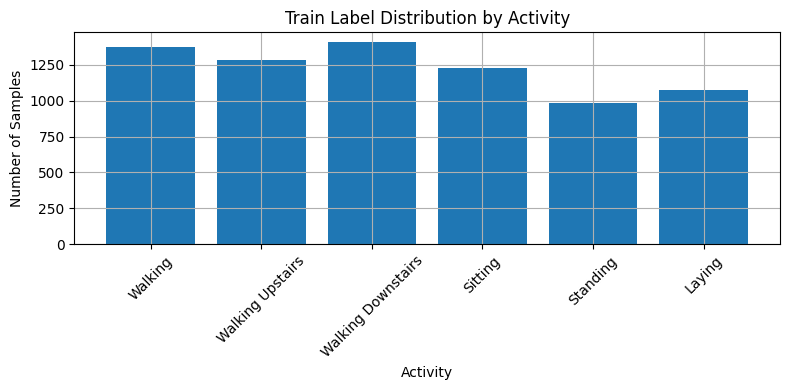

In [9]:
import matplotlib.pyplot as plt

# 막대그래프 시각화
plt.figure(figsize=(8, 4))
plt.bar(label_names.values(), train_label_counts.values())
plt.title("Train Label Distribution by Activity")
plt.xlabel("Activity")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [11]:
from torch.utils.data import DataLoader, Dataset

class SimpleDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

# 학습/검증 데이터셋 나누기 (이미 불러온 X_train, y_train 사용할 경우)
from sklearn.model_selection import train_test_split

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

train_dataset = SimpleDataset(X_train_split, y_train_split)
val_dataset = SimpleDataset(X_val_split, y_val_split)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

In [12]:
import torch.nn as nn

class iTransformerBlock(nn.Module):
    def __init__(self, dim, heads=4, ff_dim=128, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.norm1 = nn.LayerNorm(dim)
        self.ffn = nn.Sequential(nn.Linear(dim, ff_dim), nn.ReLU(), nn.Linear(ff_dim, dim))
        self.norm2 = nn.LayerNorm(dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        attn_output, _ = self.attn(x, x, x)
        x = self.norm1(x + self.dropout(attn_output))
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return x

class TransformerClassifier(nn.Module):
    def __init__(self, seq_length, in_channels=9, num_classes=6, dim=64,
                 num_blocks=4, heads=4, ff_dim=128, dropout=0.1):
        super().__init__()
        self.embed = nn.Linear(in_channels, dim)
        self.pos_embed = nn.Parameter(torch.randn(1, seq_length, dim))
        self.blocks = nn.Sequential(*[iTransformerBlock(dim, heads, ff_dim, dropout) for _ in range(num_blocks)])
        self.classifier = nn.Sequential(nn.Linear(dim, 128), nn.ReLU(), nn.Linear(128, num_classes))

    def forward(self, x):  # x: [B, C, L]
        x = x.transpose(1, 2)  # [B, L, C]
        x = self.embed(x) + self.pos_embed[:, :x.size(1)]
        x = self.blocks(x)
        return self.classifier(x.mean(dim=1))

In [13]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (logits.argmax(1) == y).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0
    preds, targets = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item()
            correct += (logits.argmax(1) == y).sum().item()
            preds.extend(logits.argmax(1).cpu().numpy())
            targets.extend(y.cpu().numpy())
    acc = correct / len(loader.dataset)
    return total_loss / len(loader), acc, preds, targets

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TransformerClassifier(
    seq_length=X_train.shape[2], in_channels=9, num_classes=6,
    dim=64, num_blocks=4
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

epochs = 100
patience = 10
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

best_val_loss = float('inf')
wait = 0

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"[{epoch+1}] Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping triggered!")
            break

[1] Train Loss: 0.6508 Acc: 0.7597 | Val Loss: 0.3095 Acc: 0.8980
[2] Train Loss: 0.2087 Acc: 0.9192 | Val Loss: 0.2143 Acc: 0.9225
[3] Train Loss: 0.1544 Acc: 0.9383 | Val Loss: 0.1564 Acc: 0.9477
[4] Train Loss: 0.1605 Acc: 0.9357 | Val Loss: 0.1219 Acc: 0.9477
[5] Train Loss: 0.1256 Acc: 0.9500 | Val Loss: 0.1169 Acc: 0.9551
[6] Train Loss: 0.1249 Acc: 0.9488 | Val Loss: 0.1086 Acc: 0.9633
[7] Train Loss: 0.1139 Acc: 0.9527 | Val Loss: 0.1109 Acc: 0.9490
[8] Train Loss: 0.1185 Acc: 0.9488 | Val Loss: 0.2515 Acc: 0.9177
[9] Train Loss: 0.1282 Acc: 0.9417 | Val Loss: 0.1085 Acc: 0.9517
[10] Train Loss: 0.1156 Acc: 0.9512 | Val Loss: 0.1042 Acc: 0.9497
[11] Train Loss: 0.1092 Acc: 0.9526 | Val Loss: 0.1164 Acc: 0.9517
[12] Train Loss: 0.1125 Acc: 0.9509 | Val Loss: 0.1119 Acc: 0.9572
[13] Train Loss: 0.1134 Acc: 0.9526 | Val Loss: 0.1157 Acc: 0.9585
[14] Train Loss: 0.1112 Acc: 0.9514 | Val Loss: 0.1272 Acc: 0.9443
[15] Train Loss: 0.1049 Acc: 0.9510 | Val Loss: 0.1093 Acc: 0.9640
[16]

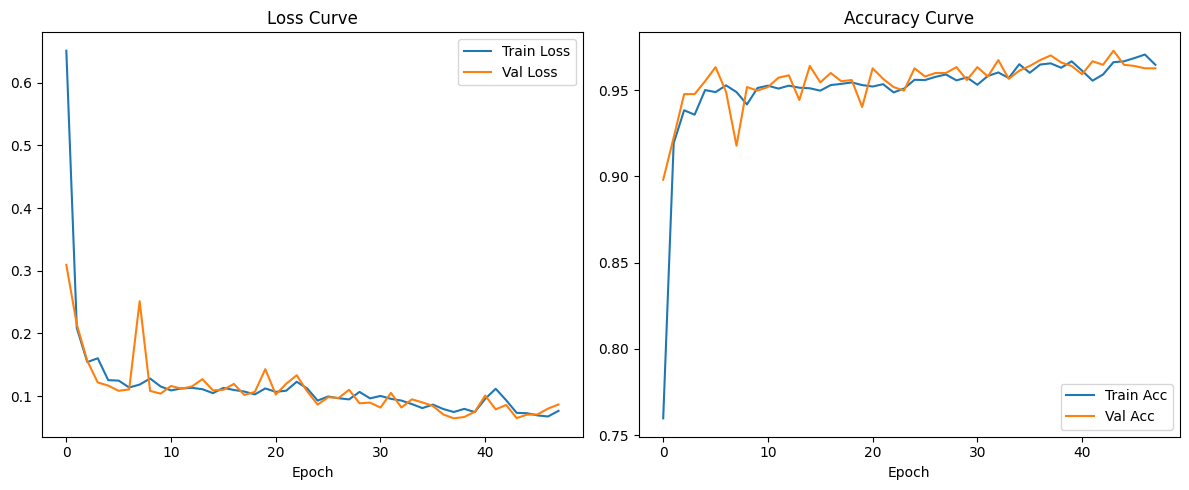

In [15]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curve'); plt.xlabel("Epoch"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Curve'); plt.xlabel("Epoch"); plt.legend()

plt.tight_layout()
plt.show()

== Classification Report ==
              precision    recall  f1-score   support

           0     0.9959    0.9959    0.9959       245
           1     0.9862    0.9953    0.9907       215
           2     1.0000    0.9898    0.9949       197
           3     0.9323    0.9105    0.9213       257
           4     0.9181    0.9382    0.9281       275
           5     1.0000    1.0000    1.0000       282

    accuracy                         0.9701      1471
   macro avg     0.9721    0.9716    0.9718      1471
weighted avg     0.9702    0.9701    0.9701      1471

F1 Score (macro): 0.9718124106246454


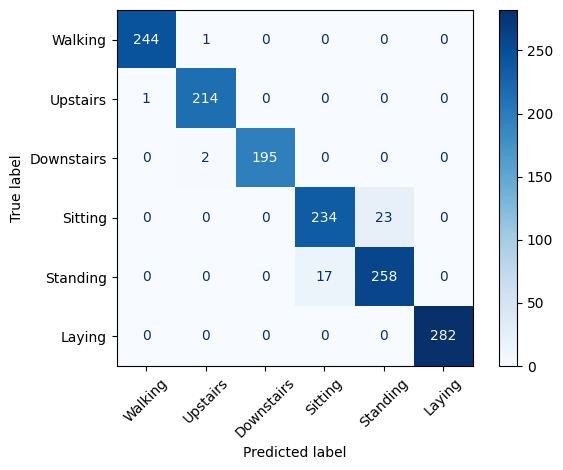

In [16]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay

model.load_state_dict(torch.load("best_model.pth"))
_, _, y_pred, y_true = evaluate(model, val_loader, criterion, device)

print("== Classification Report ==")
print(classification_report(y_true, y_pred, digits=4))

print("F1 Score (macro):", f1_score(y_true, y_pred, average="macro"))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[
    "Walking", "Upstairs", "Downstairs", "Sitting", "Standing", "Laying"
])
disp.plot(cmap="Blues", xticks_rotation=45)
plt.tight_layout()
plt.show()